# Identify frequent item sets using the Apriori algorithm for a given transaction data set.

Association rule mining on a small transaction dataset using `mlxtend`.

One-Hot Encoded Data:
    Beer  Bread  Butter  Cookies  Diapers   Milk
0  False   True    True    False    False   True
1  False   True    True    False    False  False
2   True  False   False     True     True  False
3  False   True    True    False     True   True
4   True  False   False    False     True  False

Frequent Itemsets:
   support                          itemsets
0      0.4                 frozenset({Beer})
1      0.6                frozenset({Bread})
2      0.6               frozenset({Butter})
3      0.6              frozenset({Diapers})
4      0.4                 frozenset({Milk})
5      0.4        frozenset({Diapers, Beer})
6      0.6        frozenset({Bread, Butter})
7      0.4          frozenset({Milk, Bread})
8      0.4         frozenset({Milk, Butter})
9      0.4  frozenset({Milk, Bread, Butter})

Association Rules:
                 antecedents                 consequents  support  confidence  \
0          frozenset({Beer})        frozenset({Diapers})      0.4   

C:\Users\Levono\AppData\Local\Temp\ipykernel_20872\1080848494.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=top_itemsets, palette="viridis")


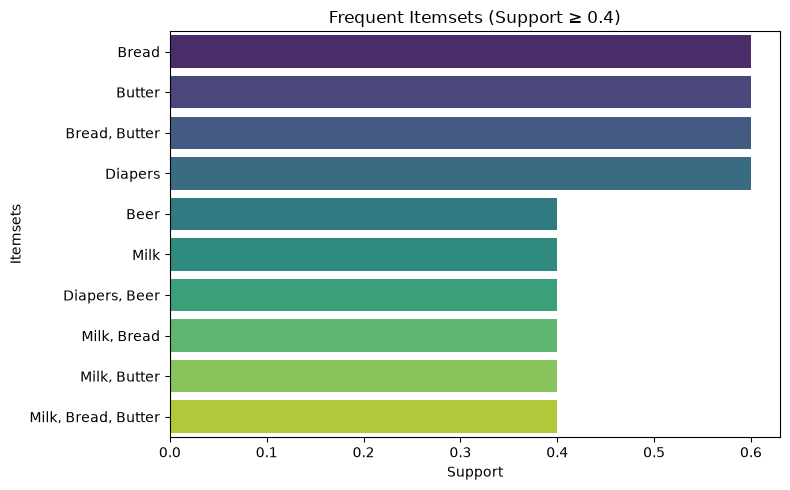

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
dataset = [
['Bread', 'Butter', 'Milk'],
['Bread', 'Butter'],
['Beer', 'Cookies', 'Diapers'],
['Milk', 'Diapers', 'Bread', 'Butter'],
['Beer', 'Diapers']
]
te = TransactionEncoder()
te_array = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_array, columns=te.columns_)
print("One-Hot Encoded Data:")
print(df)
frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
print("\nFrequent Itemsets:")
print(frequent_itemsets)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x='support', y='itemsets', data=top_itemsets, palette="viridis")
plt.title('Frequent Itemsets (Support ≥ 0.4)')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.tight_layout()
plt.show()